In [13]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from uncertainties import unumpy
from uncertainties import ufloat
import warnings
warnings.filterwarnings('ignore')

from matplotlib.patches import Circle
from sklearn.linear_model import LinearRegression
from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 16}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}


In [2]:
df =pd.read_csv('Dados/results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv('Dados/benchmark_subsample.csv', index_col='Cluster')
data = pd.read_csv('Dados/data.csv', index_col='Cluster')

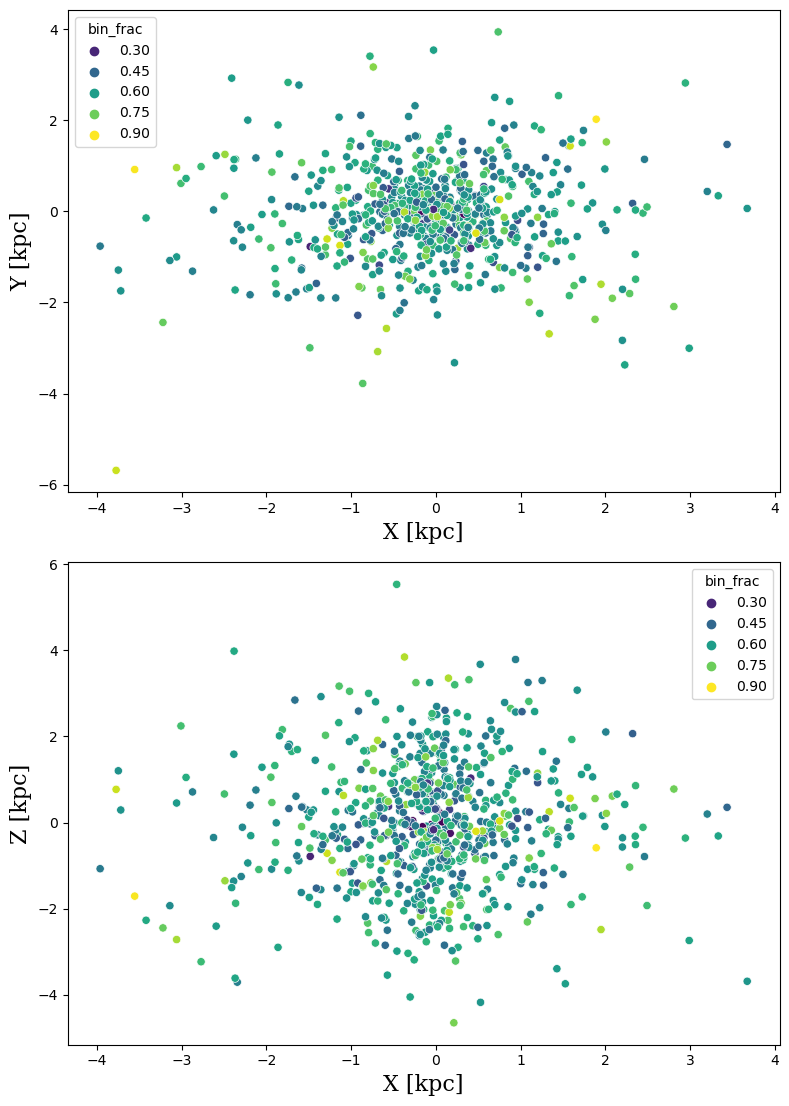

In [19]:
df['X'] = df['dist']*np.cos(df['RA_ICRS'])*np.cos(df['DE_ICRS'])
df['Y'] = df['dist']*np.sin(df['RA_ICRS'])*np.cos(df['DE_ICRS'])
df['Z'] = df['dist']*np.sin(df['DE_ICRS'])

fig, ax = plt.subplots(2,1, figsize=(8, 12))

sns.scatterplot(data=df, x='X', y='Y', hue='bin_frac', palette=palette, ax=ax[0], )
sns.scatterplot(data=df, x='X',y='Z', hue='bin_frac', palette=palette, ax =ax[1])

ax[0].set_ylabel(r'Y [kpc]', fontdict=font)
ax[0].set_xlabel(r'X [kpc]', fontdict=font)

ax[1].set_ylabel(r'Z [kpc]', fontdict=font)
ax[1].set_xlabel(r'X [kpc]', fontdict=font)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('Figures/distribuição_espacial_aglomerados.png',bbox_inches='tight', dpi=300)
plt.show()



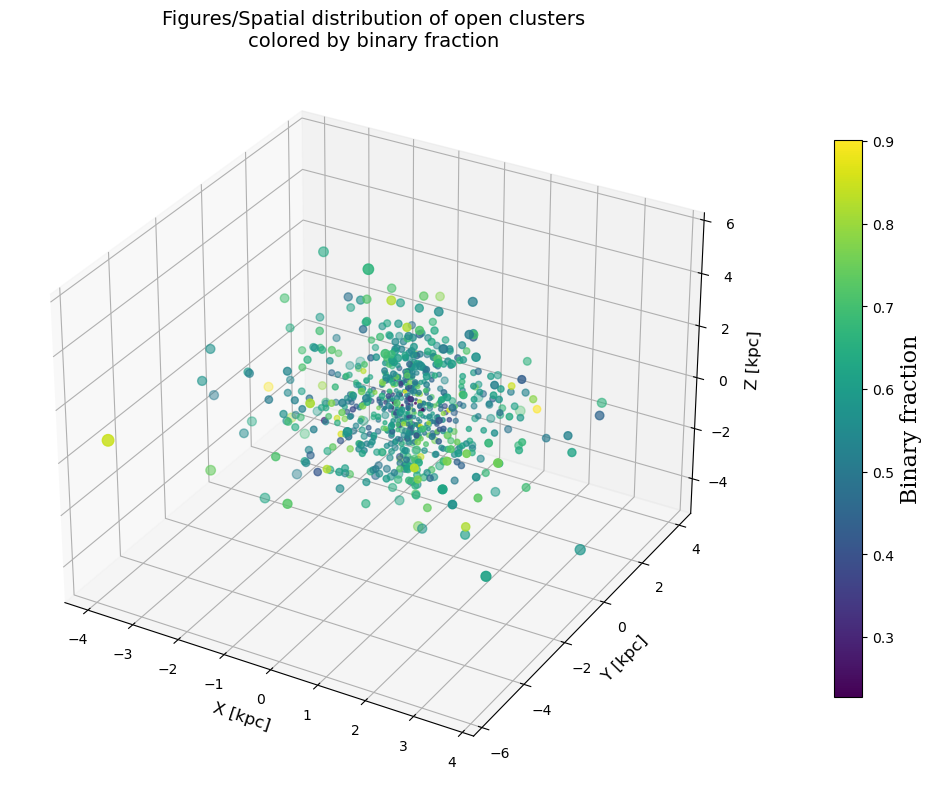

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np

# Figura e eixo 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['X']
y = df['Y']
z = df['Z']
c = df['bin_frac']

norm = plt.Normalize(c.min(), c.max())
colors = plt.cm.viridis(norm(c)) 

# Gráfico de dispersão 3D
#ax.scatter(0, 0, 0, color='red', marker='*', s=200, label='Sun')
scatter = ax.scatter(x, y, z, c=c, cmap=palette, s=10*df.dist)

# Marcar o Sol no centro


# Eixos
ax.set_xlabel('X [kpc]', fontsize=12)
ax.set_ylabel('Y [kpc]', fontsize=12)
ax.set_zlabel('Z [kpc]', fontsize=12)

# Barra de cor
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.75)
cbar.set_label('Binary fraction', fontdict=font)
cbar.ax.tick_params(labelsize=10)

# Título (opcional)
ax.set_title('Figures/Spatial distribution of open clusters\ncolored by binary fraction', fontsize=14)

# Mostrar
plt.tight_layout()
plt.show()


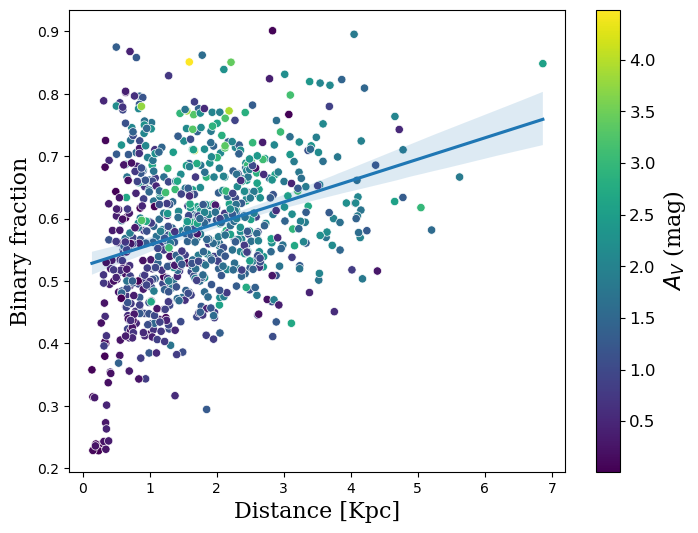

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='dist', y= 'bin_frac', hue='Av', palette=palette, legend=None)

sns.regplot(data=df, x='dist', y='bin_frac', scatter=False, )

norm = plt.Normalize(df.Av.min(), vmax=df.Av.max()) 
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm)
cbar.set_label(r'$A_V$ (mag)', fontdict=font)
cbar.ax.tick_params(labelsize=12) 

plt.xlabel('Distance [Kpc]', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.savefig('Figures/dist_fb_dist_Av.png',bbox_inches='tight', dpi=300)
plt.show()



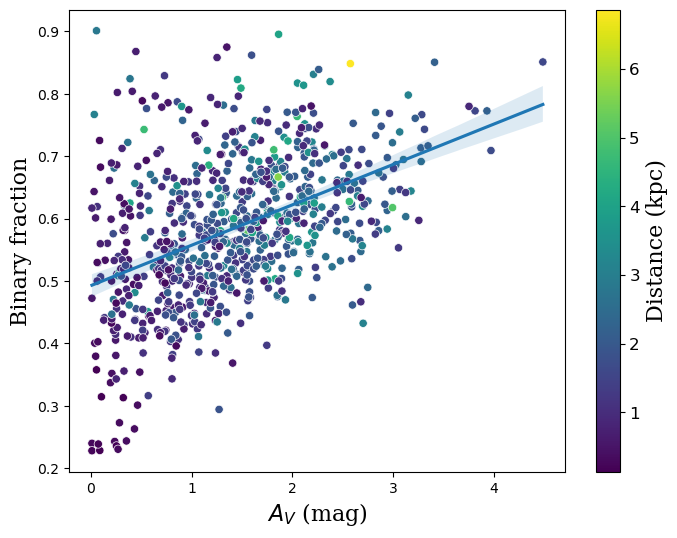

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='Av', y= 'bin_frac', hue='dist', palette=palette, legend=None)

sns.regplot(data=df, x='Av', y='bin_frac', scatter=False, )

norm = plt.Normalize(df.dist.min(), vmax=df.dist.max()) 
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm)
cbar.set_label(r'Distance (kpc)', fontdict=font)
cbar.ax.tick_params(labelsize=12) 

plt.xlabel(r'$A_V$ (mag)', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.savefig('Figures/dist_fb_Av_dist.png',bbox_inches='tight', dpi=300)
plt.show()



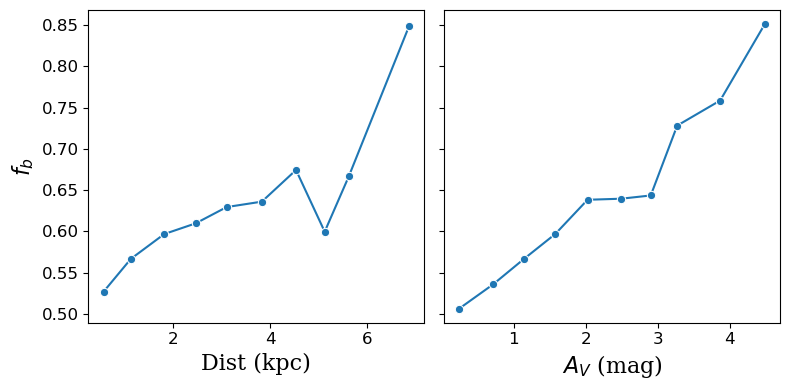

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

n_bins = 10

aux = df.copy(deep=True)
aux['dist_bin'] = pd.cut(aux['dist'], bins=n_bins)

dist_mean = (
    aux.groupby('dist_bin')
      .agg(dist_center=('dist', 'mean'),
           bin_frac_mean=('bin_frac', 'mean'))
      .reset_index()
)


sns.lineplot(data=dist_mean,
             x='dist_center',
             y='bin_frac_mean',
             marker='o',
             ax=axs[0])



aux['Av_bin'] = pd.cut(aux['Av'], bins=n_bins)

av_mean = (
    aux.groupby('Av_bin')
      .agg(Av_center=('Av', 'mean'),
           bin_frac_mean=('bin_frac', 'mean'))
      .reset_index()
)


sns.lineplot(data=av_mean,
             x='Av_center',
             y='bin_frac_mean',
             marker='o',
             ax=axs[1],)

axs[0].set_xlabel('Dist (kpc)', fontdict=font)
axs[1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0].set_ylabel(r'$f_b$', fontdict=font)
axs[0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1].tick_params(labelbottom=True, labelsize=12)
plt.tight_layout()
plt.savefig('Figures/systematic_bias.png',bbox_inches='tight', dpi=300)
plt.show()


In [53]:
df[df.dist<=0.5].bin_frac.describe()

count    46.000000
mean      0.452538
std       0.170756
min       0.227915
25%       0.313301
50%       0.437934
75%       0.555869
max       0.875000
Name: bin_frac, dtype: float64

In [52]:
df[df.dist>0.5].bin_frac.describe()

count    725.000000
mean       0.592116
std        0.104298
min        0.294118
25%        0.518987
50%        0.590278
75%        0.661538
max        0.901235
Name: bin_frac, dtype: float64